# 5 Results

Estimate and plot the fundamental frequency of a generated audio file with `librosa`.

In [48]:
import pathlib

import librosa
import matplotlib.pyplot as plt
import numpy as np

cwd = pathlib.Path.cwd()
if cwd.name == "quickstart":
    quickstart_dir = cwd
elif (cwd / "rnencodec-onehot" / "quickstart").exists():
    quickstart_dir = cwd / "rnencodec-onehot" / "quickstart"
else:
    raise FileNotFoundError("Run this notebook from the repo root or from rnencodec-onehot/quickstart.")

# Conditioning values used in 4_experiments.ipynb.
EXPERIMENT_REFERENCE_SEGMENTS = {
    "cont_A.wav": [
        {"label": "Input A4", "frequency": 440.0},
    ],
    "film_A.wav": [
        {"label": "Input A4", "frequency": 440.0},
    ],
    "class_A.wav": [
        {"label": "Input A4", "frequency": 440.0},
    ],
    "cont_C_to_D.wav": [
        {"label": "Input C4", "frequency": 261.63, "start": 0.0, "end": 2.0},
        {"label": "Input D4", "frequency": 293.66, "start": 2.0, "end": 4.0},
    ],
    "film_C_to_D.wav": [
        {"label": "Input C4", "frequency": 261.63, "start": 0.0, "end": 2.0},
        {"label": "Input D4", "frequency": 293.66, "start": 2.0, "end": 4.0},
    ],
    "class_C_to_D.wav": [
        {"label": "Input C4", "frequency": 261.63, "start": 0.0, "end": 2.0},
        {"label": "Input D4", "frequency": 293.66, "start": 2.0, "end": 4.0},
    ],
    "cont_C_major_scale.wav": [
        {"label": "Input C4", "frequency": 261.63, "start": 0.0, "end": 0.75},
        {"label": "Input D4", "frequency": 293.66, "start": 0.75, "end": 1.5},
        {"label": "Input E4", "frequency": 329.63, "start": 1.5, "end": 2.25},
        {"label": "Input F4", "frequency": 349.23, "start": 2.25, "end": 3.0},
        {"label": "Input G4", "frequency": 392.0, "start": 3.0, "end": 3.75},
        {"label": "Input A4", "frequency": 440.0, "start": 3.75, "end": 4.5},
        {"label": "Input G4", "frequency": 392.0, "start": 4.5, "end": 5.25},
        {"label": "Input F4", "frequency": 349.23, "start": 5.25, "end": 6.0},
        {"label": "Input E4", "frequency": 329.63, "start": 6.0, "end": 6.75},
        {"label": "Input D4", "frequency": 293.66, "start": 6.75, "end": 7.5},
        {"label": "Input C4", "frequency": 261.63, "start": 7.5, "end": 8.25},
    ],
    "film_C_major_scale.wav": [
        {"label": "Input C4", "frequency": 261.63, "start": 0.0, "end": 0.75},
        {"label": "Input D4", "frequency": 293.66, "start": 0.75, "end": 1.5},
        {"label": "Input E4", "frequency": 329.63, "start": 1.5, "end": 2.25},
        {"label": "Input F4", "frequency": 349.23, "start": 2.25, "end": 3.0},
        {"label": "Input G4", "frequency": 392.0, "start": 3.0, "end": 3.75},
        {"label": "Input A4", "frequency": 440.0, "start": 3.75, "end": 4.5},
        {"label": "Input G4", "frequency": 392.0, "start": 4.5, "end": 5.25},
        {"label": "Input F4", "frequency": 349.23, "start": 5.25, "end": 6.0},
        {"label": "Input E4", "frequency": 329.63, "start": 6.0, "end": 6.75},
        {"label": "Input D4", "frequency": 293.66, "start": 6.75, "end": 7.5},
        {"label": "Input C4", "frequency": 261.63, "start": 7.5, "end": 8.25},
    ],
    "class_C_major_scale.wav": [
        {"label": "Input C4", "frequency": 261.63, "start": 0.0, "end": 0.75},
        {"label": "Input D4", "frequency": 293.66, "start": 0.75, "end": 1.5},
        {"label": "Input E4", "frequency": 329.63, "start": 1.5, "end": 2.25},
        {"label": "Input F4", "frequency": 349.23, "start": 2.25, "end": 3.0},
        {"label": "Input G4", "frequency": 392.0, "start": 3.0, "end": 3.75},
        {"label": "Input A4", "frequency": 440.0, "start": 3.75, "end": 4.5},
        {"label": "Input G4", "frequency": 392.0, "start": 4.5, "end": 5.25},
        {"label": "Input F4", "frequency": 349.23, "start": 5.25, "end": 6.0},
        {"label": "Input E4", "frequency": 329.63, "start": 6.0, "end": 6.75},
        {"label": "Input D4", "frequency": 293.66, "start": 6.75, "end": 7.5},
        {"label": "Input C4", "frequency": 261.63, "start": 7.5, "end": 8.25},
    ],
}

quickstart_dir

PosixPath('/Users/oriolfreixa/Documents/GitHub/GenAI/rnencodec-onehot/quickstart')

In [49]:
def plot_fundamental_frequency(
    audio_path,
    *,
    sr=None,
    fmin=120.41,
    fmax=500.0,
    frame_length=2048,
    hop_length=256,
    reference_segments=None,
):
    """Load an audio file, estimate its F0, and optionally overlay the input frequencies."""
    audio_path = pathlib.Path(audio_path)
    if not audio_path.is_absolute() and not audio_path.exists():
        audio_path = (quickstart_dir / audio_path).resolve()

    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    if reference_segments is None:
        reference_segments = EXPERIMENT_REFERENCE_SEGMENTS.get(audio_path.name, [])
    elif np.isscalar(reference_segments):
        reference_segments = [{"label": "Input", "frequency": float(reference_segments)}]
    elif isinstance(reference_segments, dict):
        reference_segments = [reference_segments]

    fmin_hz = float(fmin)
    fmax_hz = float(fmax)
    if fmin_hz >= fmax_hz:
        raise ValueError("fmin must be lower than fmax.")

    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y,
        sr=sr,
        fmin=fmin_hz,
        fmax=fmax_hz,
        frame_length=frame_length,
        hop_length=hop_length,
    )
    times = librosa.times_like(f0, sr=sr, hop_length=hop_length)

    voiced_f0 = f0[~np.isnan(f0)]
    total_duration = float(times[-1]) if times.size else 0.0
    reference_descriptions = []
    reference_colors = ["tab:green", "tab:red", "tab:purple", "tab:brown"]

    plt.figure(figsize=(12, 4))
    #plt.plot(times, f0, color="tab:blue", linewidth=1.5, label="Estimated F0")
    for idx, segment in enumerate(reference_segments):
        frequency = float(segment["frequency"])
        start = float(segment.get("start", 0.0))
        end = segment.get("end", total_duration)
        end = total_duration if end is None else float(end)
        label = segment.get("label", "Input")
        color = reference_colors[idx % len(reference_colors)]
        plt.hlines(
            frequency,
            start,
            end,
            colors=color,
            linestyles="--",
            linewidth=2,
            label=f"{label}: {frequency:.2f} Hz",
        )
        x_position = start if end <= start else start + (end - start) / 2
        plt.annotate(
            f"{label}\n{frequency:.2f} Hz",
            xy=(x_position, frequency),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color=color,
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": color, "alpha": 0.85},
        )
        if end < total_duration:
            reference_descriptions.append(f"{label}: {frequency:.2f} Hz from {start:.2f}s to {end:.2f}s")
        else:
            reference_descriptions.append(f"{label}: {frequency:.2f} Hz")
    plt.scatter(times[voiced_flag], f0[voiced_flag], s=10, color="tab:orange", alpha=0.6, label="Voiced frames")
    plt.title(f"Fundamental Frequency: {audio_path.name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(fmin_hz, fmax_hz * 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if reference_descriptions:
        print("Input conditioning:")
        for description in reference_descriptions:
            print(f"  - {description}")

    if voiced_f0.size:
        print(f"Voiced frames: {voiced_f0.size}/{f0.size}")
        print(f"Median F0: {np.median(voiced_f0):.2f} Hz")
        print(f"Mean F0: {np.mean(voiced_f0):.2f} Hz")
    else:
        print("No voiced frames were detected in the selected range.")

    return times, f0, voiced_prob


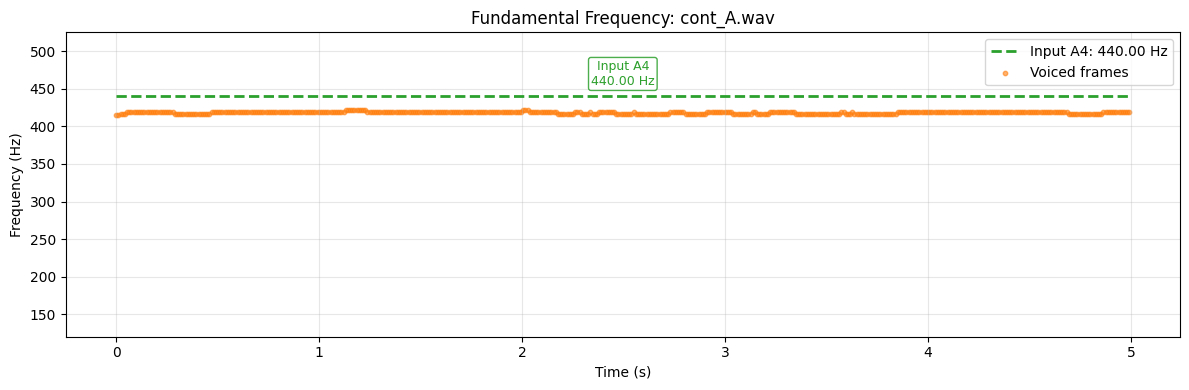

Input conditioning:
  - Input A4: 440.00 Hz
Voiced frames: 469/469
Median F0: 419.29 Hz
Mean F0: 418.60 Hz


In [50]:
audio_path = quickstart_dir / "experiments_output" / "cont_A.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path)

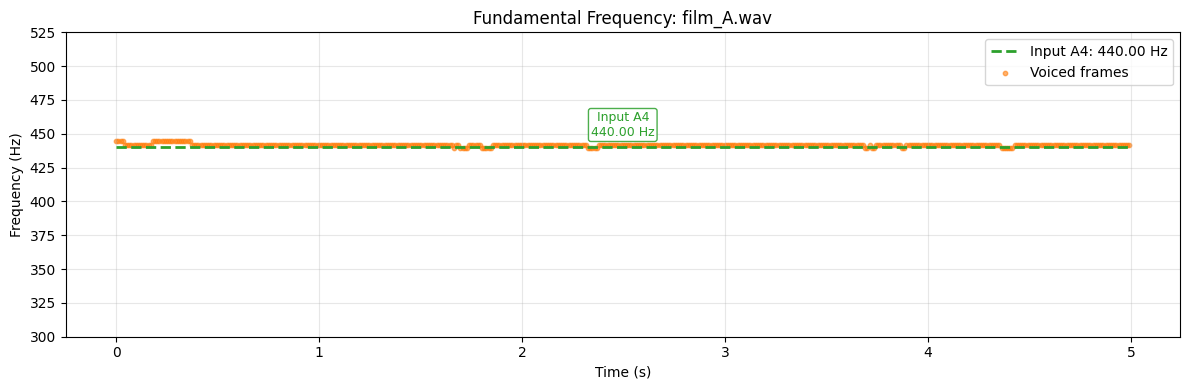

Input conditioning:
  - Input A4: 440.00 Hz
Voiced frames: 469/469
Median F0: 441.77 Hz
Mean F0: 441.74 Hz


In [59]:
audio_path = quickstart_dir / "experiments_output" / "film_A.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=300)

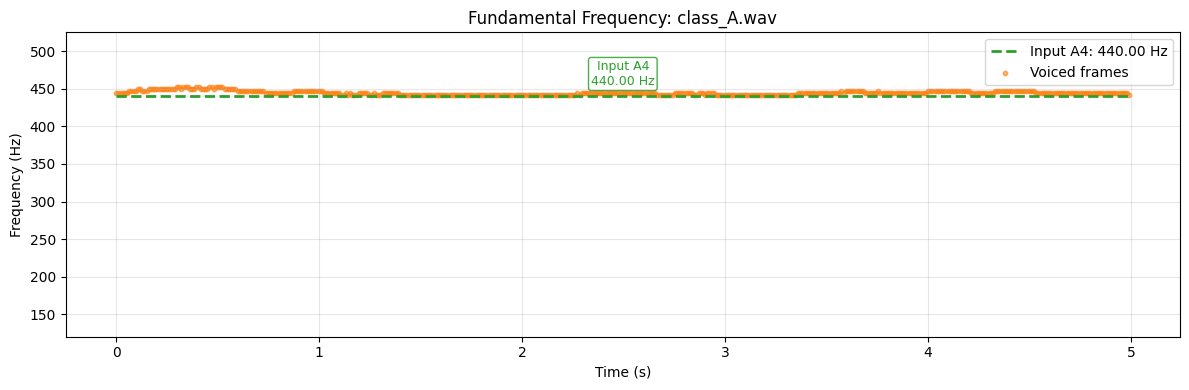

Input conditioning:
  - Input A4: 440.00 Hz
Voiced frames: 469/469
Median F0: 444.22 Hz
Mean F0: 444.45 Hz


In [ ]:
audio_path = quickstart_dir / "experiments_output" / "class_A.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=300)

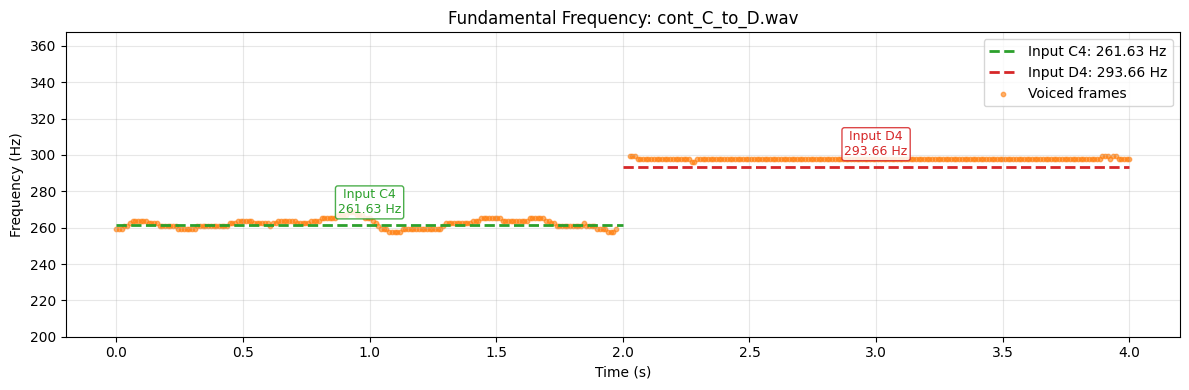

Input conditioning:
  - Input C4: 261.63 Hz from 0.00s to 2.00s
  - Input D4: 293.66 Hz
Voiced frames: 372/376
Median F0: 282.37 Hz
Mean F0: 280.15 Hz


In [61]:
audio_path = quickstart_dir / "experiments_output" / "cont_C_to_D.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=200, fmax=350)

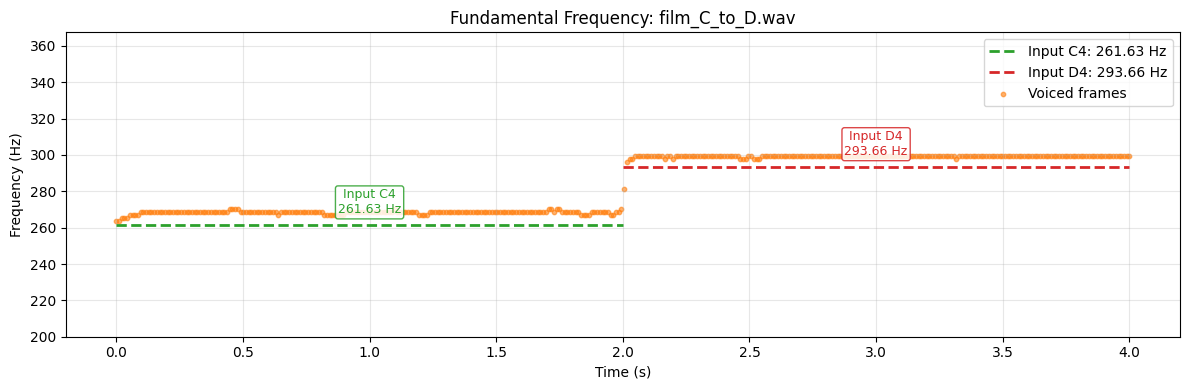

Input conditioning:
  - Input C4: 261.63 Hz from 0.00s to 2.00s
  - Input D4: 293.66 Hz
Voiced frames: 376/376
Median F0: 275.64 Hz
Mean F0: 283.88 Hz


In [62]:
audio_path = quickstart_dir / "experiments_output" / "film_C_to_D.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=200, fmax=350)

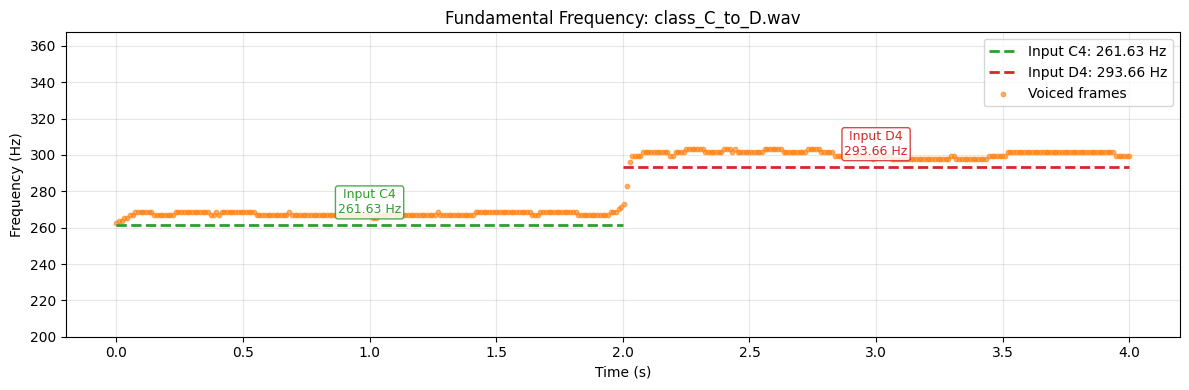

Input conditioning:
  - Input C4: 261.63 Hz from 0.00s to 2.00s
  - Input D4: 293.66 Hz
Voiced frames: 376/376
Median F0: 272.42 Hz
Mean F0: 283.92 Hz


In [63]:
audio_path = quickstart_dir / "experiments_output" / "class_C_to_D.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=200, fmax=350)

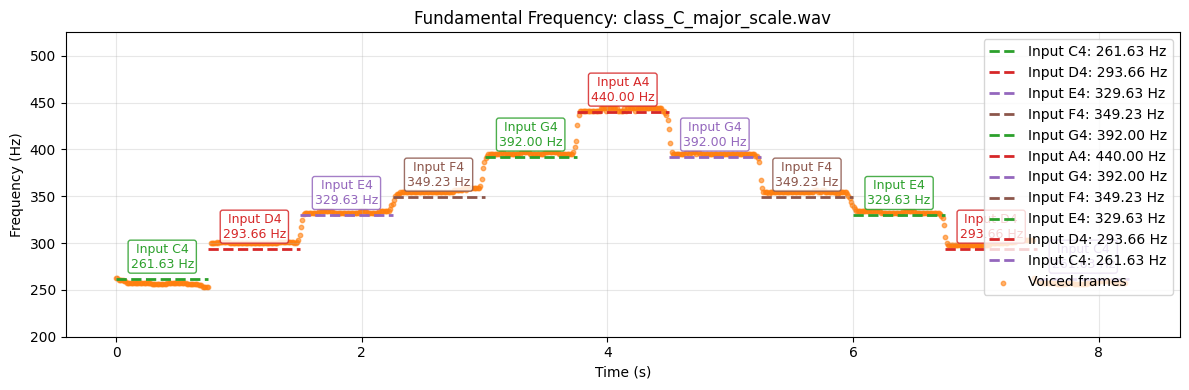

Input conditioning:
  - Input C4: 261.63 Hz from 0.00s to 0.75s
  - Input D4: 293.66 Hz from 0.75s to 1.50s
  - Input E4: 329.63 Hz from 1.50s to 2.25s
  - Input F4: 349.23 Hz from 2.25s to 3.00s
  - Input G4: 392.00 Hz from 3.00s to 3.75s
  - Input A4: 440.00 Hz from 3.75s to 4.50s
  - Input G4: 392.00 Hz from 4.50s to 5.25s
  - Input F4: 349.23 Hz from 5.25s to 6.00s
  - Input E4: 329.63 Hz from 6.00s to 6.75s
  - Input D4: 293.66 Hz from 6.75s to 7.50s
  - Input C4: 261.63 Hz
Voiced frames: 770/771
Median F0: 334.42 Hz
Mean F0: 338.82 Hz


In [56]:
audio_path = quickstart_dir / "experiments_output" / "class_C_major_scale.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=200.0)

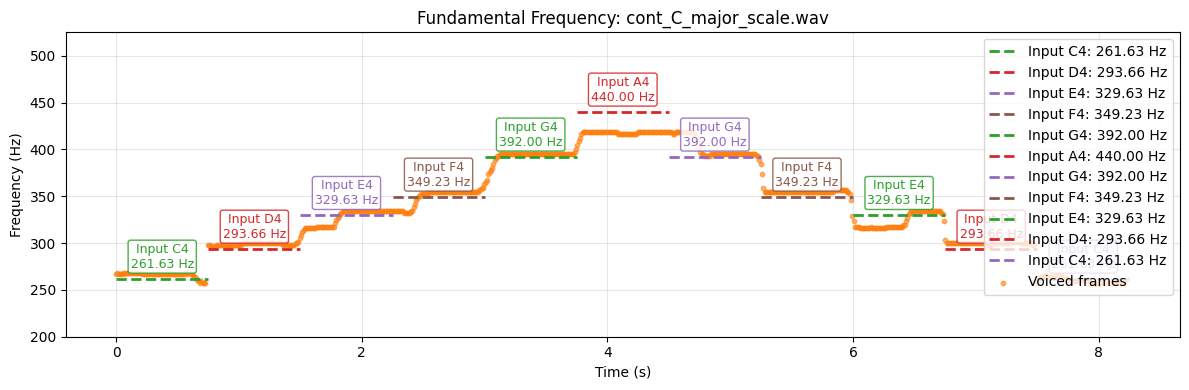

Input conditioning:
  - Input C4: 261.63 Hz from 0.00s to 0.75s
  - Input D4: 293.66 Hz from 0.75s to 1.50s
  - Input E4: 329.63 Hz from 1.50s to 2.25s
  - Input F4: 349.23 Hz from 2.25s to 3.00s
  - Input G4: 392.00 Hz from 3.00s to 3.75s
  - Input A4: 440.00 Hz from 3.75s to 4.50s
  - Input G4: 392.00 Hz from 4.50s to 5.25s
  - Input F4: 349.23 Hz from 5.25s to 6.00s
  - Input E4: 329.63 Hz from 6.00s to 6.75s
  - Input D4: 293.66 Hz from 6.75s to 7.50s
  - Input C4: 261.63 Hz
Voiced frames: 769/771
Median F0: 334.42 Hz
Mean F0: 336.13 Hz


In [64]:
audio_path = quickstart_dir / "experiments_output" / "cont_C_major_scale.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=200.0)

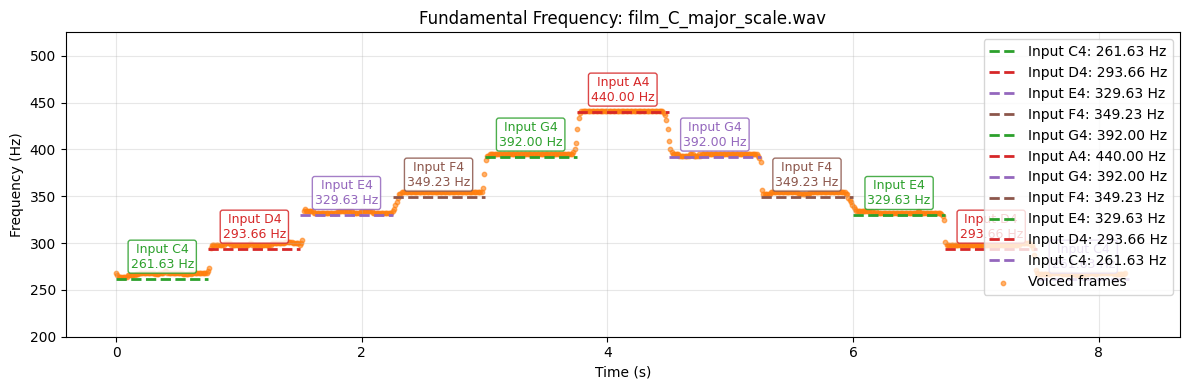

Input conditioning:
  - Input C4: 261.63 Hz from 0.00s to 0.75s
  - Input D4: 293.66 Hz from 0.75s to 1.50s
  - Input E4: 329.63 Hz from 1.50s to 2.25s
  - Input F4: 349.23 Hz from 2.25s to 3.00s
  - Input G4: 392.00 Hz from 3.00s to 3.75s
  - Input A4: 440.00 Hz from 3.75s to 4.50s
  - Input G4: 392.00 Hz from 4.50s to 5.25s
  - Input F4: 349.23 Hz from 5.25s to 6.00s
  - Input E4: 329.63 Hz from 6.00s to 6.75s
  - Input D4: 293.66 Hz from 6.75s to 7.50s
  - Input C4: 261.63 Hz
Voiced frames: 771/771
Median F0: 334.42 Hz
Mean F0: 339.65 Hz


In [65]:
audio_path = quickstart_dir / "experiments_output" / "film_C_major_scale.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path, fmin=200.0)